### Libraries

In [1]:
# Numerical libraries
import numpy as np
import pandas as pd
# from scipy.signal import savgol_filter

# Machine learning and data preprocessing libraries
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import MinMaxScaler

# Plotting library
import matplotlib.pyplot as plt

# TensorFlow and Keras libraries for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, SimpleRNN, LSTM
from tensorflow.keras.models import Sequential

# Other imports (if necessary)
from keras.layers import SimpleRNN as KerasSimpleRNN
from keras.layers import Layer
from keras import backend as K
import sys


## Data Collection

In [8]:
# def soft_robot_kinematics(servo_angles):
#     """A kinematic model for the soft robot using delta robot principles, accounting for deformation."""
    
#     # Constants
#     BASE_HEIGHT = 1.0
#     MAX_CABLE_EFFECT = 5.0
#     ARM_LENGTH = 20.0
#     BASE_RADIUS = 2.5
#     DEFORMATION_FACTOR = 1  # This factor determines the lateral movement due to deformation. Adjust as needed.
    
#     # Cable length adjustment based on servo angle
#     cable_lengths = [(angle / 180.0) * MAX_CABLE_EFFECT for angle in servo_angles]
    
#     # Compute effective arm lengths
#     effective_lengths = [ARM_LENGTH - cable for cable in cable_lengths]
    
#     # Calculate deformation effect on x and y
#     deformation_x = DEFORMATION_FACTOR * (cable_lengths[0] - cable_lengths[2])
#     deformation_y = DEFORMATION_FACTOR * (2*cable_lengths[1] - cable_lengths[0] - cable_lengths[2])
    
#     # Position of each of the 'spheres' 
#     A = [BASE_RADIUS + deformation_x, deformation_y, effective_lengths[0]]
#     B = [-BASE_RADIUS/2 + deformation_x/2, BASE_RADIUS*np.sqrt(3)/2 + deformation_y/2, effective_lengths[1]]
#     C = [-BASE_RADIUS/2 + deformation_x/2, -BASE_RADIUS*np.sqrt(3)/2 + deformation_y/2, effective_lengths[2]]
    
#     # Compute the end effector's position
#     x = (A[0] + B[0] + C[0]) / 3.0
#     y = (A[1] + B[1] + C[1]) / 3.0
#     z = BASE_HEIGHT + np.mean([A[2], B[2], C[2]])
    
#     return np.array([x, y, z])

    

# def generate_data(num_samples=10000, noise_std=1):
#     # Systematic servo angles
#     systematic_angles = np.arange(15, 165, 10)
    
#     # Generating data samples
#     servo_angles = []
#     target_positions = []
#     for _ in range(num_samples // len(systematic_angles)):
#         for angle in systematic_angles:
#             angle_set = [
#                 angle + np.random.randint(-5, 5),  # Random perturbations
#                 angle + np.random.randint(-5, 5),
#                 angle + np.random.randint(-5, 5)
#             ]
#             servo_angles.append(angle_set)
            
#             # Kinematic simulation
#             end_position = soft_robot_kinematics(np.array(angle_set))
#             target_positions.append(end_position)
    
#     # Add noise to target_positions to get the 'observed' positions (mimicking computer vision noise)
#     observed_positions = np.array(target_positions) + np.random.normal(0, noise_std, size=(len(target_positions), 3))
    
#     # Rounding the numbers to two decimal places
#     observed_positions = np.round(observed_positions, 2)
#     servo_angles = np.round(np.array(servo_angles), 2)
#     target_positions = np.round(np.array(target_positions), 2)
    
#     return servo_angles, target_positions, observed_positions

# servo_data, target_positions, observed_positions = generate_data()


In [9]:
# servo_data, target_positions, observed_positions = generate_data()

# # Create the DataFrame
# df = pd.DataFrame({
#     'Servo_Angles': ["({}, {}, {})".format(ang1, ang2, ang3) for ang1, ang2, ang3 in servo_data],
#     'Target_Position': ["({}, {}, {})".format(x, y, z) for x, y, z in target_positions],
#     'Observed_Position': ["({}, {}, {})".format(x, y, z) for x, y, z in observed_positions],
# })

# # Display the DataFrame
# df.head()


In [2]:
# create data from PCC model
from kinematics_functions import T_beModule, invKspace
from point_clouds import generate_random_points
from add_error_to_kin import add_error_to_kin
from ISTlogo_traj import ISTlogo_traj

# jt2l = lambda p: ((p-316.1)/-2.468)

# cab_traj = generate_random_points(25, 160, 10000, 5)
# cab_traj_err = [add_error_to_kin(cab_traj[i+1], cab_traj[i], 0, 0, 0, 0, 0) for i in range(len(cab_traj)-1)]
# pcc_traj = [T_beModule(traj, [], 0, None)[:-1, 3] for traj in cab_traj[1:]]

# y_target = np.array(pcc_traj)
# x_train = np.array(cab_traj[1:])
# y_train = np.array([T_beModule(traj, [], 0, None)[:-1, 3] for traj in cab_traj_err])

traj = np.array(ISTlogo_traj()[0])

jtheta2len = lambda p: (p - 383.89841) / -2.53968 # polaris readings
x_test = jtheta2len(traj)
y_test = np.array([T_beModule(traj, [], 0, None)[:-1, 3] for traj in x_test])

# print(len(x_train), len(y_train), len(y_target))

# # Create the DataFrame
# df = pd.DataFrame({
#     'Servo_Angles': ["({}, {}, {})".format(*angs) for angs in x_train],
#     'Servo_Angles (w/ err)': ["({:.2f}, {:.2f}, {:.2f})".format(*angs) for angs in cab_traj_err],
#     'Target_Position': ["({:.2f}, {:.2f}, {:.2f})".format(*pos) for pos in y_target],
#     'Observed_Position': ["({:.2f}, {:.2f}, {:.2f})".format(*pos) for pos in y_train],
# })

# # Display the DataFrame
# df.head()


In [3]:
# read data from Polaris dataset
from read_datafile import parse_dataset
from kinematics_functions import T_beModule

# datasets = ["./data/dataset_1001_2023-11-14T123514.txt"]

datasets = ["./data/dataset_1001_2023-11-23T162547.txt"]
# datasets.append(["./data/dataset_1001_2023-11-17T161724.txt", ])

datasets_result = []

for filename in datasets:
    dx = -19.5; dy = -104.06; dz = -81.31; alpha = 45 * np.pi / 180; beta = 0
    
    traj, ref_T, pos = parse_dataset(filename)
    mask = ~np.isnan(ref_T).all(axis=2)[:,1] # remove Nan transforms
    traj = traj[mask]
    ref_T = ref_T[mask]
    pos = pos[mask]

    ref_p = ref_T[:,0:3,3]
    ref_R = ref_T[:,0:3,0:3]

    pos_ref = np.array([ref_R[i].T @ (pos[i] - ref_p[i]) for i in range(len(pos))])
    
    base_R = np.array([[1, 0, 0],
                       [0, np.cos(alpha), -np.sin(alpha)],
                       [0, np.sin(alpha), np.cos(alpha)]])

    # final data
    pos_base = (pos_ref - np.array([[dx, dy, dz]])) @ base_R @ np.array([[0,0,1],
                                                                         [-1,0,0],
                                                                         [0,1,0]])
    if traj[0][0] > 500:
        jtheta2len = lambda p: (p - 4488.62157) / -26.03760 # writeMicroseconds, polaris readings
        # jtheta2len = lambda p: (p - 4552.15581) / -25.86452 # writeMicroseconds, manual readings
    else: 
        jtheta2len = lambda p: (p - 383.89841) / -2.53968 # polaris readings
        # jtheta2len = lambda p: (p - 384.1) / -2.48336 # manual readings

    traj_ = jtheta2len(traj) # cable lengths

    if beta == 0:
        est_pos_base = np.array([T_beModule(p, [], 0, 0)[0:3,3] for p in traj_])
    else: 
        R_pcc_to_base = np.array([[np.cos(beta), -np.sin(beta), 0],
                                  [np.sin(beta), np.cos(beta), 0],
                                  [0, 0, 1]])
        est_pos_base = np.array([T_beModule(p, [], 0, 0)[0:3,3] @ R_pcc_to_base for p in traj_])

    datasets_result.append({"traj": traj, "traj_": traj_, "pos_base": pos_base, "est_pos_base": est_pos_base})

# print(datasets_result[0].get("traj").shape, '\n',
#       datasets_result[0].get("traj")[:5], '\n',
#       datasets_result[0].get("traj_")[:5], '\n',
#       datasets_result[0].get("pos_base")[:5], '\n',
#       datasets_result[0].get("est_pos_base")[:5], '\n',)


## Data Preprocessing

In [12]:
# Custom Transformer for servo feedback filtration
class ServoFeedbackFilter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return savgol_filter(X, 5, 3, axis=0)

# Custom Transformer for relative angles
class RelativeAngles(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.diff(X, axis=1)

# Preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('servo_feedback_filter', ServoFeedbackFilter()),
    ('relative_angles', RelativeAngles()),
    ('scaler', MinMaxScaler())
])

# Using the pipeline to transform data
processed_data = preprocessing_pipeline.fit_transform(servo_data)


NameError: name 'BaseEstimator' is not defined

In [4]:
# Polaris data preprocessing

for dataset in datasets_result:
    rel_err_norm = np.linalg.norm(dataset.get("pos_base") - dataset.get("est_pos_base"), axis=1)  / np.linalg.norm(dataset.get("est_pos_base"), axis=1)
    # print(max(rel_err_norm))
    filtered_dataset = {key: value[rel_err_norm < .05] for key, value in dataset.items()}

# print(filtered_dataset.get("traj").shape, '\n',
#       filtered_dataset.get("traj")[:5], '\n',
#       filtered_dataset.get("traj_")[:5], '\n',
#       filtered_dataset.get("pos_base")[:5], '\n',
#       filtered_dataset.get("est_pos_base")[:5], '\n',)

y_train = filtered_dataset.get("pos_base")
x_train = filtered_dataset.get("traj_")

print(filtered_dataset.get("traj").shape)


(610, 3)


## Model Design & Selection

In [5]:
class DNNModelBuilder:

    def __init__(self, input_data, architectures):
        """
        :param input_data: data used to determine the input shape
        :param architectures: list of functions. Each function should return a compiled tf.keras.model.
        """
        self.input_data = input_data
        self.architectures = architectures
        self.models = [arch(input_data) for arch in architectures]
        self.histories = []

    def train(self, data, labels, epochs=50, batch_size=32, validation_split=0.2):
        for i, model in enumerate(self.models):
            print(f"Training model {i + 1}/{len(self.models)}")
            history = model.fit(data, labels, epochs=epochs, batch_size=batch_size, validation_split=validation_split)
            self.histories.append(history)  # Store training history for future analysis

    def predict(self, data):
        predictions = []
        for model in self.models:
            predictions.append(model.predict(data))
        return predictions

    def evaluate(self, data, labels):
        """Evaluate models on given data and labels, returns loss values."""
        losses = []
        for model in self.models:
            loss = model.evaluate(data, labels)
            losses.append(loss)
        return losses

    def save_models(self, prefix="model"):
        """Store models to disk."""
        for i, model in enumerate(self.models):
            model.save(f"{prefix}_{i}.keras")

    def compare_models(self):
        """Compare training histories visually."""
        for i, history in enumerate(self.histories):
            plt.plot(history.history['val_loss'], label=f"Model {i + 1}: {str(self.architectures[i]).split(' ')[1]}")

        plt.title('Model Comparison on Validation Loss')
        plt.ylabel('Validation Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.ylim([0, np.mean([np.mean(history.history['val_loss'] * 1.5) for history in self.histories])])
        plt.show()


##### Several types of architectures

def FeedforwardDNN(data, optimizer='adam', loss='mse'):
    """
    Feedforward DNN
    A basic feedforward architecture with multiple hidden layers.
    
    # Example Usage:
    model_feedforward = FeedforwardDNN(processed_data)
    model_feedforward.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def SimpleFNN_60(data, optimizer='adam', loss='mse'):
    """
    Feedforward NN
    A basic feedforward architecture with 1 hidden layer.
    
    # Example Usage:
    model_feedforward = FeedforwardNN(processed_data)
    model_feedforward.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(60, activation='relu', input_shape=input_shape))
    model.add(Dense(60, activation='relu', input_shape=input_shape))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def SimpleFNN_30(data, optimizer='adam', loss='mse'):
    """
    Feedforward NN
    A basic feedforward architecture with 1 hidden layer.
    
    # Example Usage:
    model_feedforward = FeedforwardNN(processed_data)
    model_feedforward.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(30, activation='relu', input_shape=input_shape))
    model.add(Dense(30, activation='relu', input_shape=input_shape))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def SimpleFNN_15(data, optimizer='adam', loss='mse'):
    """
    Feedforward NN
    A basic feedforward architecture with 1 hidden layer.
    
    # Example Usage:
    model_feedforward = FeedforwardNN(processed_data)
    model_feedforward.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(15, activation='relu', input_shape=input_shape))
    model.add(Dense(15, activation='relu', input_shape=input_shape))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

class RBFLayer(Layer):
    def __init__(self, units, gamma, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.units = units
        self.gamma = K.cast_to_floatx(gamma)

    def build(self, input_shape):
        self.mu = self.add_weight(name='mu',
                                  shape=(int(input_shape[1]), self.units),
                                  initializer='uniform',
                                  trainable=True)
        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        diff = K.expand_dims(inputs) - self.mu
        l2 = K.sum(K.pow(diff,2), axis=1)
        res = K.exp(-1 * self.gamma * l2)
        return res

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

def SimpleRBFNN(data, optimizer='adam', loss='mse'):
    input_shape = (data.shape[1],)
    input_layer = keras.layers.Input(shape=input_shape)
    model = Sequential()
    # model.add(Dense(20, activation='relu', input_shape=input_shape))
    model.add(RBFLayer(20, 0.5, input_shape=input_shape))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def ResNet(data, optimizer='adam', loss='mse'):
    """
    Deep Residual Network (ResNet)
    A deep network with skip connections.
    
    # Example Usage:
    model_resnet = ResNet(processed_data)
    model_resnet.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    input_layer = tf.keras.layers.Input(shape=input_shape)
    x = Dense(128, activation='relu')(input_layer)
    for _ in range(3):
        y = Dense(128, activation='relu')(x)
        y = Dense(128, activation='relu')(y)
        x = tf.keras.layers.add([x, y])
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output_layer = Dense(3)(x)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss=loss)
    return model

def DropoutDNN(data, optimizer='adam', loss='mse'):
    """
    Dropout Regularized (DNN)
    A feedforward architecture with dropout layers.
    
    # Example Usage:
    model_dropout = DropoutDNN(processed_data)
    model_dropout.fit(processed_data, target_positions, epochs=10)
    """
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model


def SimpleRNN(data, optimizer='adam', loss='mse'):
    """
    Recurrent Neural Network (RNN)
    Useful for temporal sequences.
    """
    # Check for 3D shape, if not, try to reshape
    if len(data.shape) == 2:
        data = data.reshape(data.shape[0], data.shape[1], 1)
    input_shape = (data.shape[1], data.shape[2])
    model = Sequential()
    model.add(KerasSimpleRNN(128, return_sequences=True, input_shape=input_shape))
    model.add(KerasSimpleRNN(64, return_sequences=True))
    model.add(KerasSimpleRNN(32))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model

def LSTM(data, optimizer='adam', loss='mse'):
    input_shape = (data.shape[1],)
    model = Sequential()
    model.add(Dense(20, input_shape=input_shape))
    model.add(LSTM(20))
    model.add(Dense(3))
    model.compile(optimizer=optimizer, loss=loss)
    return model


Training model 1/4
Epoch 1/2000
8/8 [==============================] - 1s 32ms/step - loss: 4383.5483 - val_loss: 3903.3540
Epoch 2/2000
8/8 [==============================] - 0s 6ms/step - loss: 3854.9456 - val_loss: 3421.5854
Epoch 3/2000
8/8 [==============================] - 0s 6ms/step - loss: 3403.0752 - val_loss: 3014.7856
Epoch 4/2000
8/8 [==============================] - 0s 5ms/step - loss: 3022.4688 - val_loss: 2679.1267
Epoch 5/2000
8/8 [==============================] - 0s 5ms/step - loss: 2715.0017 - val_loss: 2406.7336
Epoch 6/2000
8/8 [==============================] - 0s 6ms/step - loss: 2462.5293 - val_loss: 2191.5991
Epoch 7/2000
8/8 [==============================] - 0s 5ms/step - loss: 2265.1897 - val_loss: 2022.4893
Epoch 8/2000
8/8 [==============================] - 0s 5ms/step - loss: 2109.8901 - val_loss: 1890.4622
Epoch 9/2000
8/8 [==============================] - 0s 5ms/step - loss: 1988.3793 - val_loss: 1786.7084
Epoch 10/2000
8/8 [=========================

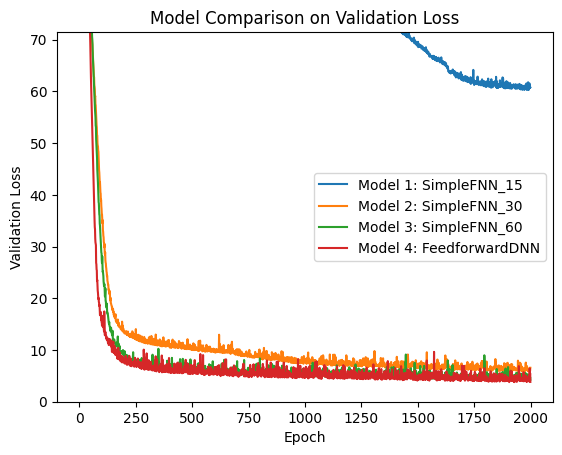

3/3 [==============================] - 0s 3ms/step - loss: 3.9681


In [6]:
# Using the model builder
builder = DNNModelBuilder(x_train, [SimpleFNN_15, SimpleFNN_30, SimpleFNN_60, FeedforwardDNN])

builder.train(x_train, y_train, epochs=2000, batch_size=64, validation_split=0.2)
builder.compare_models()
losses = builder.evaluate(x_test, y_test)
# print(losses)
# builder.save_models()


In [7]:
def plot_positions_comparison(real_positions, predicted_positions):
    # Extracting x, y, z coordinates for real positions
    x_real = real_positions[:, 0]
    y_real = real_positions[:, 1]
    z_real = real_positions[:, 2]

    # Extracting x, y, z coordinates for predicted positions
    x_pred = predicted_positions[:, 0]
    y_pred = predicted_positions[:, 1]
    z_pred = predicted_positions[:, 2]

    # Creating the figure
    fig = go.Figure()

    # Adding real positions trace
    fig.add_trace(go.Scatter3d(x=x_real, y=y_real, z=z_real,
                               mode='markers+lines', 
                               marker=dict(size=3, color='blue', symbol='circle'),
                               name='Real Positions'))

    # Adding predicted positions trace
    fig.add_trace(go.Scatter3d(x=x_pred, y=y_pred, z=z_pred,
                               mode='markers+lines', 
                               marker=dict(size=3, color='red', symbol='x'),
                               name='Predicted Positions'))

    # Update plot layout
    fig.update_layout(
        title='Real vs Predicted End Effector Positions',
        scene=dict(
            xaxis_title='X Axis',
            yaxis_title='Y Axis',
            zaxis_title='Z Axis'
        ),
        margin=dict(r=10, l=10, b=10, t=30)
    )

    # Show the plot
    fig.show()


In [8]:
import plotly.graph_objects as go
pred = builder.predict(x_test)

for i, p in enumerate(pred):
    plot_positions_comparison(np.array(y_test), np.array(p))
    rel_err = np.abs(np.linalg.norm(p - y_test, axis=1)) / np.abs(np.linalg.norm(y_test, axis=1)) * 100
    print(f"Architechture: {str(builder.architectures[i]).split(' ')[1]}")
    print(f"Mean Relative Error: {np.mean(rel_err):.3f}%")
    print(f"Max Relative Error: {max(rel_err):.3f}%")

    

3/3 [==============================] - 0s 2ms/step


Architechture: SimpleFNN_15
Mean Relative Error: 6.388%
Max Relative Error: 9.667%


Architechture: SimpleFNN_30
Mean Relative Error: 3.327%
Max Relative Error: 5.681%


Architechture: SimpleFNN_60
Mean Relative Error: 3.062%
Max Relative Error: 6.104%


Architechture: FeedforwardDNN
Mean Relative Error: 2.875%
Max Relative Error: 6.578%
